In [2]:
import pickle
import numpy as np
import pandas as pd
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import train_test_split
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index

with open('quantized_matrix_1148.pkl', 'rb') as f:
    quantized_matrix_1148 = pickle.load(f)

with open('disease_regulons.pkl', 'rb') as f:
    disease_regulons = pickle.load(f)

with open('program_activity.pkl', 'rb') as f:
    program_activity = pickle.load(f)

with open('state_labels.pkl', 'rb') as f:
    state_series = pickle.load(f)

with open('cox_results.pkl', 'rb') as f:
    cox_results = pickle.load(f)

# Load survival data
with open('eigengenes.pkl', 'rb') as f:
    eigengenes = pickle.load(f)

print(quantized_matrix_1148.shape)  # (1148, 437)
print(program_activity.shape)       # (11, 437)
print(state_series.value_counts())

(1148, 437)
(11, 437)
1    266
0    171
Name: count, dtype: int64


In [3]:
with open('clinical_clean.pkl', 'rb') as f:
    clinical_clean = pickle.load(f)

print(clinical_clean.shape)
print(clinical_clean.head())

(435, 2)
              OS_STATUS  OS_MONTHS
PATIENT_ID                        
TCGA-02-0004          1      11.33
TCGA-02-0015          1      20.60
TCGA-02-0016          1      86.99
TCGA-02-0023          1      20.11
TCGA-02-0025          1      42.71


In [4]:
def compute_guan_rank(survival_df):
    """
    GuanRank: complete hazard ranking for right-censored survival data.
    Score > 0.5 = high risk, Score < 0.5 = low risk.
    """
    df = survival_df.copy().reset_index()
    n = len(df)
    scores = np.zeros(n)
    
    for i in range(n):
        t_i = df['OS_MONTHS'].iloc[i]
        e_i = df['OS_STATUS'].iloc[i]
        
        if e_i == 1:  # event observed
            # Proportion of patients who survived longer
            longer = ((df['OS_MONTHS'] > t_i)).sum()
            scores[i] = longer / (n - 1)
        else:  # censored
            # Proportion of patients who died before censoring time
            died_before = ((df['OS_MONTHS'] < t_i) & (df['OS_STATUS'] == 1)).sum()
            scores[i] = 1 - died_before / (n - 1)
    
    df['GuanRank'] = scores
    return df.set_index('PATIENT_ID')['GuanRank']

guan_scores = compute_guan_rank(clinical_clean)
print(f"GuanRank scores: {len(guan_scores)}")
print(f"Mean: {guan_scores.mean():.3f}")
print(f"High risk (>0.5): {(guan_scores > 0.5).sum()}")
print(f"Low risk (<=0.5): {(guan_scores <= 0.5).sum()}")

GuanRank scores: 435
Mean: 0.512
High risk (>0.5): 218
Low risk (<=0.5): 217


In [10]:
# Align patients
common_patients = program_activity.columns.intersection(guan_scores.index)
print(f"Common patients: {len(common_patients)}")

X_risk = program_activity[common_patients].T.values  # 435 × 11
y_risk = guan_scores[common_patients].values

# 70/10/20 split per paper
X_train, X_test, y_train, y_test = train_test_split(
    X_risk, y_risk, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.125, random_state=42)

# Ridge regression
alphas = np.logspace(-3, 3, 100)
ridge = RidgeCV(alphas=alphas, cv=5)
ridge.fit(X_train, y_train)

y_pred_test = ridge.predict(X_test)
ci_test = concordance_index(y_test, y_pred_test)
print(f"C-index on TCGA test set: {ci_test:.4f}")

Common patients: 435
C-index on TCGA test set: 0.5276


In [11]:
with open('gravendeel_aligned.pkl', 'rb') as f:
    gravendeel_aligned = pickle.load(f)

with open('grav_survival_aligned.pkl', 'rb') as f:
    grav_survival_aligned = pickle.load(f)

with open('decomposed.pkl', 'rb') as f:
    decomposed = pickle.load(f)

print(gravendeel_aligned.shape)
print(grav_survival_aligned.shape)
print(len(decomposed))

(12680, 252)
(252, 2)
1148


In [13]:
# Redefining get_eigengene and quantize_matrix_fast functions

def quantize_matrix_fast(expr_df, regulon_indices, regulon_list):
    patients = expr_df.columns.tolist()
    n_genes = len(expr_df)
    
    gene_to_idx = {g: i for i, g in enumerate(expr_df.index)}
    
    regulon_gene_idx = {}
    for reg_idx in regulon_indices:
        genes = regulon_list[reg_idx]
        idx_list = [gene_to_idx[g] for g in genes if g in gene_to_idx]
        if len(idx_list) >= 3:
            regulon_gene_idx[reg_idx] = np.array(idx_list)
    
    valid_regulons = list(regulon_gene_idx.keys())
    n_patients = len(patients)
    
    result = np.zeros((len(valid_regulons), n_patients), dtype=np.int8)
    lower_thresh = n_genes / 3
    upper_thresh = 2 * n_genes / 3
    expr_values = expr_df.values
    
    for j in range(n_patients):
        if j % 50 == 0:
            print(f"Patient {j}/{n_patients}...")
        
        ranks = pd.Series(expr_values[:, j]).rank(method='average').values
        
        for i, reg_idx in enumerate(valid_regulons):
            gene_idx = regulon_gene_idx[reg_idx]
            reg_ranks = ranks[gene_idx]
            n = len(reg_ranks)
            
            upper = int((reg_ranks > upper_thresh).sum())
            lower = int((reg_ranks < lower_thresh).sum())
            
            p_upper = binomtest(upper, n, 1/3, alternative='greater').pvalue
            p_lower = binomtest(lower, n, 1/3, alternative='greater').pvalue
            
            if p_upper <= 0.05:
                result[i, j] = 1
            elif p_lower <= 0.05:
                result[i, j] = -1
    
    return pd.DataFrame(result, index=valid_regulons, columns=patients)



In [14]:
# Quantize Gravendeel
from scipy.stats import binomtest
grav_quantized = quantize_matrix_fast(gravendeel_aligned, list(range(len(decomposed))), decomposed)
print(f"Gravendeel quantized: {grav_quantized.shape}")
print(pd.Series(grav_quantized.values.flatten()).value_counts())

Patient 0/252...
Patient 50/252...
Patient 100/252...
Patient 150/252...
Patient 200/252...
Patient 250/252...
Gravendeel quantized: (1144, 252)
 0    224542
 1     33018
-1     30728
Name: count, dtype: int64


In [16]:
# Load program_series from programs notebook
with open('program_series.pkl', 'rb') as f:
    program_series = pickle.load(f)

# Compute program activity for Gravendeel
common_regulons_grav = grav_quantized.index.intersection(program_series.index)
print(f"Common regulons: {len(common_regulons_grav)}")

grav_program_activity = pd.DataFrame(index=range(11), columns=grav_quantized.columns)

for prog in range(11):
    regs_in_prog = program_series[program_series == prog].index.tolist()
    regs_in_prog_grav = [r for r in regs_in_prog if r in grav_quantized.index]
    if len(regs_in_prog_grav) > 0:
        grav_program_activity.loc[prog] = grav_quantized.loc[regs_in_prog_grav].mean(axis=0)
    else:
        grav_program_activity.loc[prog] = 0

grav_program_activity = grav_program_activity.astype(float)
print(f"Gravendeel program activity: {grav_program_activity.shape}")  # (11, 252)

# Predict GuanRank scores
X_grav = grav_program_activity.T.values  # 252 × 11
y_pred_grav = ridge.predict(X_grav)

# Compute C-index against Gravendeel survival
from lifelines.utils import concordance_index

grav_survival_aligned = grav_survival_aligned.dropna()
common_grav_patients = grav_program_activity.columns.intersection(grav_survival_aligned.index)
print(f"Common Gravendeel patients: {len(common_grav_patients)}")

X_grav_aligned = grav_program_activity[common_grav_patients].T.values
y_pred_grav_aligned = ridge.predict(X_grav_aligned)
y_true_grav = grav_survival_aligned.loc[common_grav_patients, 'OS_MONTHS'].values

ci_grav = concordance_index(y_true_grav, -y_pred_grav_aligned)
print(f"C-index on Gravendeel: {ci_grav:.4f}")

Common regulons: 573
Gravendeel program activity: (11, 252)
Common Gravendeel patients: 252
C-index on Gravendeel: 0.6233


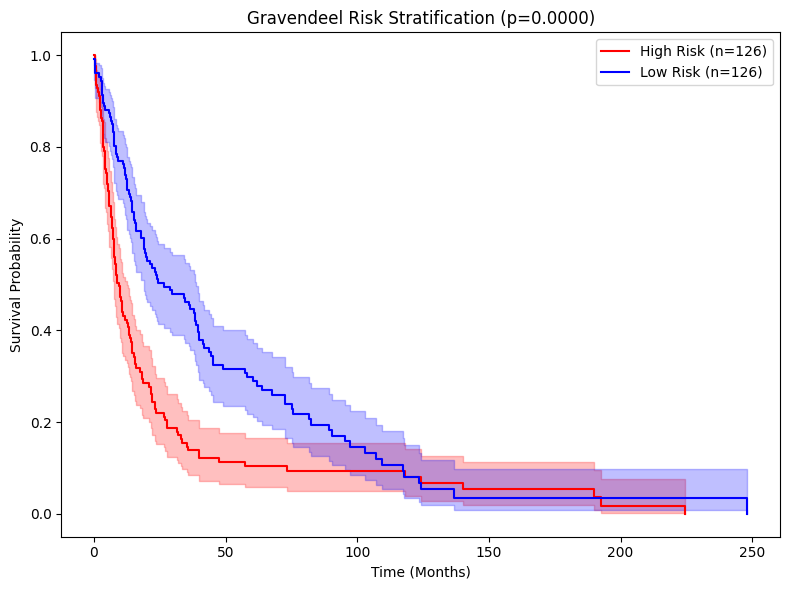

Log-rank p-value: 1.3503e-05


In [17]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

# Stratify Gravendeel patients into high/low risk
grav_risk_scores = pd.Series(y_pred_grav_aligned, index=common_grav_patients)
high_risk = grav_risk_scores[grav_risk_scores > grav_risk_scores.median()].index
low_risk = grav_risk_scores[grav_risk_scores <= grav_risk_scores.median()].index

kmf = KaplanMeierFitter()
fig, ax = plt.subplots(figsize=(8, 6))

kmf.fit(grav_survival_aligned.loc[high_risk, 'OS_MONTHS'],
        grav_survival_aligned.loc[high_risk, 'OS_STATUS'],
        label=f'High Risk (n={len(high_risk)})')
kmf.plot_survival_function(ax=ax, color='red')

kmf.fit(grav_survival_aligned.loc[low_risk, 'OS_MONTHS'],
        grav_survival_aligned.loc[low_risk, 'OS_STATUS'],
        label=f'Low Risk (n={len(low_risk)})')
kmf.plot_survival_function(ax=ax, color='blue')

from lifelines.statistics import logrank_test
results = logrank_test(
    grav_survival_aligned.loc[high_risk, 'OS_MONTHS'],
    grav_survival_aligned.loc[low_risk, 'OS_MONTHS'],
    event_observed_A=grav_survival_aligned.loc[high_risk, 'OS_STATUS'],
    event_observed_B=grav_survival_aligned.loc[low_risk, 'OS_STATUS']
)

ax.set_title(f'Gravendeel Risk Stratification (p={results.p_value:.4f})')
ax.set_xlabel('Time (Months)')
ax.set_ylabel('Survival Probability')
plt.tight_layout()
plt.savefig('km_gravendeel.png', dpi=150)
plt.show()
print(f"Log-rank p-value: {results.p_value:.4e}")

Fold 1/5...
Fold 2/5...
Fold 3/5...
Fold 4/5...
Fold 5/5...
C-index (5-fold CV): 0.5291


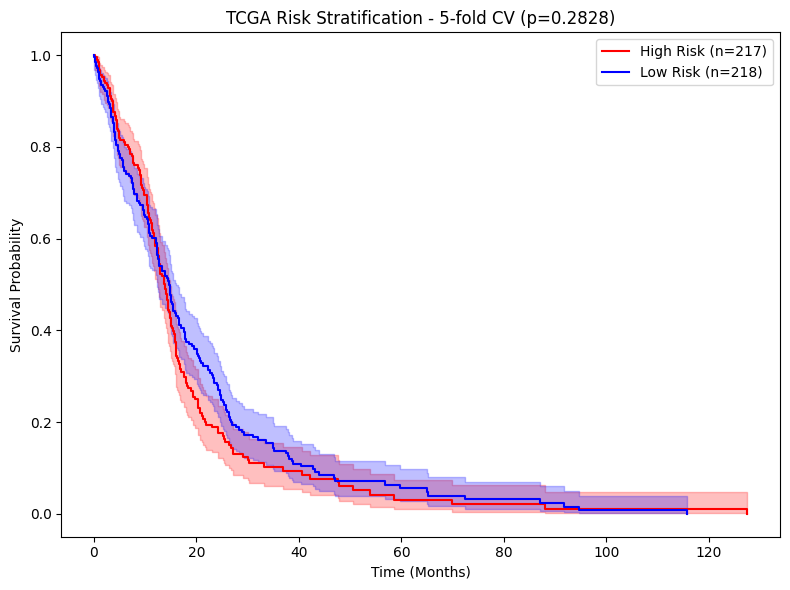

Log-rank p-value: 2.8279e-01


In [20]:
from sklearn.model_selection import KFold
import numpy as np

# 5-fold cross-validation to get out-of-fold predictions
kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_predictions = np.zeros(len(common_patients))

for fold, (train_idx, val_idx) in enumerate(kf.split(X_risk)):
    print(f"Fold {fold+1}/5...")
    X_tr, X_val = X_risk[train_idx], X_risk[val_idx]
    y_tr = y_risk[train_idx]
    
    ridge_cv = RidgeCV(alphas=np.logspace(-3, 3, 100), cv=5)
    ridge_cv.fit(X_tr, y_tr)
    oof_predictions[val_idx] = ridge_cv.predict(X_val)

# C-index on OOF predictions
ci_oof = concordance_index(y_risk, oof_predictions)
print(f"C-index (5-fold CV): {ci_oof:.4f}")

# KM plot on full cohort using OOF predictions
oof_series = pd.Series(oof_predictions, index=common_patients)
high_risk_tcga = oof_series[oof_series > oof_series.median()].index
low_risk_tcga = oof_series[oof_series <= oof_series.median()].index

kmf = KaplanMeierFitter()
fig, ax = plt.subplots(figsize=(8, 6))

kmf.fit(clinical_clean.loc[high_risk_tcga, 'OS_MONTHS'],
        clinical_clean.loc[high_risk_tcga, 'OS_STATUS'],
        label=f'High Risk (n={len(high_risk_tcga)})')
kmf.plot_survival_function(ax=ax, color='red')

kmf.fit(clinical_clean.loc[low_risk_tcga, 'OS_MONTHS'],
        clinical_clean.loc[low_risk_tcga, 'OS_STATUS'],
        label=f'Low Risk (n={len(low_risk_tcga)})')
kmf.plot_survival_function(ax=ax, color='blue')

results_tcga = logrank_test(
    clinical_clean.loc[high_risk_tcga, 'OS_MONTHS'],
    clinical_clean.loc[low_risk_tcga, 'OS_MONTHS'],
    event_observed_A=clinical_clean.loc[high_risk_tcga, 'OS_STATUS'],
    event_observed_B=clinical_clean.loc[low_risk_tcga, 'OS_STATUS']
)

ax.set_title(f'TCGA Risk Stratification - 5-fold CV (p={results_tcga.p_value:.4f})')
ax.set_xlabel('Time (Months)')
ax.set_ylabel('Survival Probability')
plt.tight_layout()
plt.savefig('km_tcga_cv.png', dpi=150)
plt.show()
print(f"Log-rank p-value: {results_tcga.p_value:.4e}")